<a href="https://colab.research.google.com/github/rishitharaj/AI-Gen-AI---GANs/blob/main/GAN_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**AI and GenAI Assignment**

**Objective:**
To implement and train a simple Generative Adversarial Network (GAN) using TensorFlow
(Keras API) to generate handwritten digit images that resemble the MNIST dataset.
This mini-assignment aims to strengthen your understanding of adversarial learning and
generative modeling.

In [ ]:
# Import libraries

import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
# Load MNIST dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize to [-1, 1]
x_train = (x_train - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1).astype("float32")

BUFFER_SIZE = 60000
BATCH_SIZE = 256

# Dataset pipeline
dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Generator Model

def build_generator():
    model = tf.keras.Sequential()

    model.add(layers.Dense(7*7*256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))

    model.add(layers.Conv2DTranspose(128, 5, strides=1,
                                     padding="same",
                                     use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, 5, strides=2,
                                     padding="same",
                                     use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, 5, strides=2,
                                     padding="same",
                                     use_bias=False,
                                     activation="tanh"))
    return model

In [ ]:
# Discriminator Model
def build_discriminator():
    model = tf.keras.Sequential()

    model.add(layers.Conv2D(64, 5, strides=2,
                            padding="same",
                            input_shape=[28,28,1]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, 5, strides=2,
                            padding="same"))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation="sigmoid"))
    return model

In [ ]:
# Create Models
generator = build_generator()
discriminator = build_discriminator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Loss Functions

cross_entropy = tf.keras.losses.BinaryCrossentropy()

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

In [ ]:
# Optimizer
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

In [ ]:
# Training
EPOCHS = 20
noise_dim = 100
num_examples_to_generate = 16

seed = tf.random.normal([num_examples_to_generate, noise_dim])

gen_loss_history = []
disc_loss_history = []

In [ ]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    gen_gradients = gen_tape.gradient(
        gen_loss, generator.trainable_variables
    )
    disc_gradients = disc_tape.gradient(
        disc_loss, discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(gen_gradients, generator.trainable_variables)
    )
    discriminator_optimizer.apply_gradients(
        zip(disc_gradients, discriminator.trainable_variables)
    )

    return gen_loss, disc_loss

In [ ]:
# Save generated images
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4,4))

    for i in range(predictions.shape[0]):
        plt.subplot(4,4,i+1)
        plt.imshow(predictions[i,:,:,0]*127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.suptitle(f"Epoch {epoch}")
    plt.show()

In [ ]:
def train(dataset, epochs):
    for epoch in range(epochs):
        epoch_gen_loss = []
        epoch_disc_loss = []

        for step, image_batch in enumerate(dataset):
            gen_loss, disc_loss = train_step(image_batch)

            epoch_gen_loss.append(gen_loss)
            epoch_disc_loss.append(disc_loss)

            # Verbose: print every 50 batches
            if step % 50 == 0:
                print(f"Epoch {epoch+1}, Step {step}, "
                      f"G_loss={gen_loss:.4f}, "
                      f"D_loss={disc_loss:.4f}")

        gen_loss_history.append(
            tf.reduce_mean(epoch_gen_loss).numpy()
        )
        disc_loss_history.append(
            tf.reduce_mean(epoch_disc_loss).numpy()
        )

        print(f"Epoch {epoch+1} Summary: "
              f"G_loss={gen_loss_history[-1]:.4f}, "
              f"D_loss={disc_loss_history[-1]:.4f}")

        # NEW: display generated images every 5 epochs
        if (epoch + 1) % 5 == 0:
            generate_and_save_images(generator, epoch + 1, seed)

Epoch 1, Step 0, G_loss=0.6012, D_loss=1.4196
Epoch 1, Step 50, G_loss=0.6910, D_loss=1.3422
Epoch 1, Step 100, G_loss=0.7716, D_loss=1.3158
Epoch 1, Step 150, G_loss=0.8663, D_loss=1.3129
Epoch 1, Step 200, G_loss=0.7214, D_loss=1.3513
Epoch 1 Summary: G_loss=0.7655, D_loss=1.3324
Epoch 2, Step 0, G_loss=0.7393, D_loss=1.3749
Epoch 2, Step 50, G_loss=0.7290, D_loss=1.3602
Epoch 2, Step 100, G_loss=0.5731, D_loss=1.4996
Epoch 2, Step 150, G_loss=0.7344, D_loss=1.3907
Epoch 2, Step 200, G_loss=0.7416, D_loss=1.3496
Epoch 2 Summary: G_loss=0.7880, D_loss=1.3233
Epoch 3, Step 0, G_loss=0.8551, D_loss=1.2405
Epoch 3, Step 50, G_loss=0.7714, D_loss=1.3640
Epoch 3, Step 100, G_loss=0.7667, D_loss=1.3239
Epoch 3, Step 150, G_loss=0.7635, D_loss=1.3190
Epoch 3, Step 200, G_loss=0.7106, D_loss=1.3400
Epoch 3 Summary: G_loss=0.7655, D_loss=1.3304
Epoch 4, Step 0, G_loss=0.6953, D_loss=1.3788
Epoch 4, Step 50, G_loss=0.6877, D_loss=1.3570
Epoch 4, Step 100, G_loss=0.8317, D_loss=1.3551
Epoch 4, S

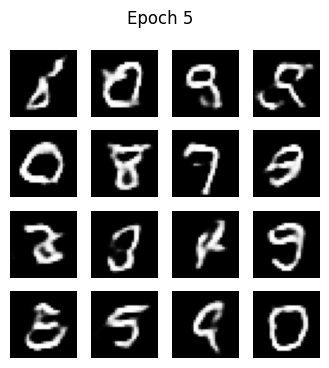

Epoch 6, Step 0, G_loss=0.7487, D_loss=1.3712
Epoch 6, Step 50, G_loss=0.7353, D_loss=1.3346
Epoch 6, Step 100, G_loss=0.7189, D_loss=1.3289
Epoch 6, Step 150, G_loss=0.7653, D_loss=1.3651
Epoch 6, Step 200, G_loss=0.8054, D_loss=1.3453
Epoch 6 Summary: G_loss=0.7606, D_loss=1.3318
Epoch 7, Step 0, G_loss=0.8075, D_loss=1.3085
Epoch 7, Step 50, G_loss=0.7184, D_loss=1.2842
Epoch 7, Step 100, G_loss=0.5813, D_loss=1.4862
Epoch 7, Step 150, G_loss=0.7768, D_loss=1.1385
Epoch 7, Step 200, G_loss=0.8980, D_loss=1.1631
Epoch 7 Summary: G_loss=0.8066, D_loss=1.3065
Epoch 8, Step 0, G_loss=0.9431, D_loss=1.1464
Epoch 8, Step 50, G_loss=0.9613, D_loss=1.4004
Epoch 8, Step 100, G_loss=0.7728, D_loss=1.3057
Epoch 8, Step 150, G_loss=0.9290, D_loss=1.2970
Epoch 8, Step 200, G_loss=0.7314, D_loss=1.3121
Epoch 8 Summary: G_loss=0.7804, D_loss=1.3195
Epoch 9, Step 0, G_loss=0.8418, D_loss=1.2929
Epoch 9, Step 50, G_loss=0.8647, D_loss=1.3508
Epoch 9, Step 100, G_loss=0.8263, D_loss=1.3452
Epoch 9, S

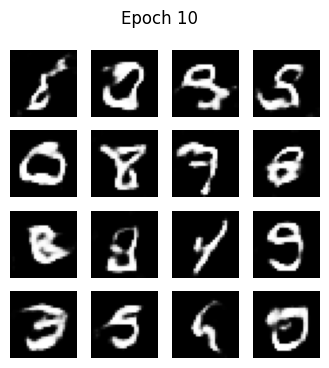

Epoch 11, Step 0, G_loss=0.8953, D_loss=1.5023
Epoch 11, Step 50, G_loss=1.1061, D_loss=1.1971
Epoch 11, Step 100, G_loss=0.6345, D_loss=1.3829
Epoch 11, Step 150, G_loss=0.8031, D_loss=1.3019
Epoch 11, Step 200, G_loss=0.8114, D_loss=1.3002
Epoch 11 Summary: G_loss=0.7849, D_loss=1.3190
Epoch 12, Step 0, G_loss=0.7884, D_loss=1.3398
Epoch 12, Step 50, G_loss=0.7129, D_loss=1.3233
Epoch 12, Step 100, G_loss=0.7194, D_loss=1.3490
Epoch 12, Step 150, G_loss=0.8445, D_loss=1.3080
Epoch 12, Step 200, G_loss=0.7347, D_loss=1.2989
Epoch 12 Summary: G_loss=0.7777, D_loss=1.3213
Epoch 13, Step 0, G_loss=0.8204, D_loss=1.3385
Epoch 13, Step 50, G_loss=1.0017, D_loss=1.1738
Epoch 13, Step 100, G_loss=0.6678, D_loss=1.4300
Epoch 13, Step 150, G_loss=0.7178, D_loss=1.3135
Epoch 13, Step 200, G_loss=0.7299, D_loss=1.3316
Epoch 13 Summary: G_loss=0.8118, D_loss=1.3054
Epoch 14, Step 0, G_loss=0.8153, D_loss=1.2613
Epoch 14, Step 50, G_loss=0.7963, D_loss=1.2917
Epoch 14, Step 100, G_loss=0.7841, D_l

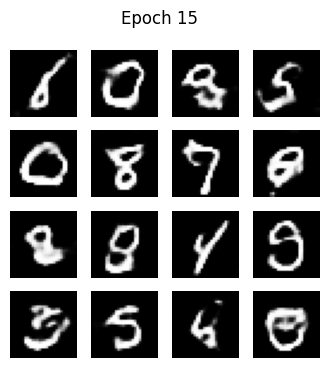

Epoch 16, Step 0, G_loss=0.7961, D_loss=1.2936
Epoch 16, Step 50, G_loss=0.6852, D_loss=1.3383
Epoch 16, Step 100, G_loss=0.6871, D_loss=1.3011
Epoch 16, Step 150, G_loss=0.7734, D_loss=1.3035
Epoch 16, Step 200, G_loss=0.7407, D_loss=1.3240
Epoch 16 Summary: G_loss=0.7865, D_loss=1.3156
Epoch 17, Step 0, G_loss=0.6805, D_loss=1.3404
Epoch 17, Step 50, G_loss=0.7072, D_loss=1.3175
Epoch 17, Step 100, G_loss=0.9116, D_loss=1.3169
Epoch 17, Step 150, G_loss=0.7159, D_loss=1.2815
Epoch 17, Step 200, G_loss=0.9031, D_loss=1.2086
Epoch 17 Summary: G_loss=0.7986, D_loss=1.3129
Epoch 18, Step 0, G_loss=0.8721, D_loss=1.3262
Epoch 18, Step 50, G_loss=0.7309, D_loss=1.3212
Epoch 18, Step 100, G_loss=0.7771, D_loss=1.2470
Epoch 18, Step 150, G_loss=0.8338, D_loss=1.3202
Epoch 18, Step 200, G_loss=0.9197, D_loss=1.3423
Epoch 18 Summary: G_loss=0.8104, D_loss=1.3043
Epoch 19, Step 0, G_loss=0.7077, D_loss=1.3834
Epoch 19, Step 50, G_loss=0.5983, D_loss=1.3967
Epoch 19, Step 100, G_loss=0.6050, D_l

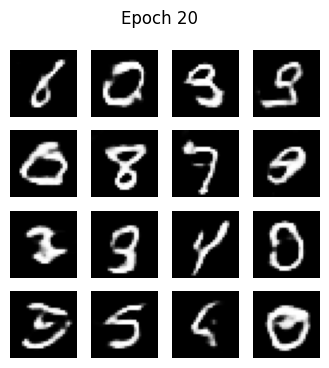

In [ ]:
# Start training
train(dataset, EPOCHS)

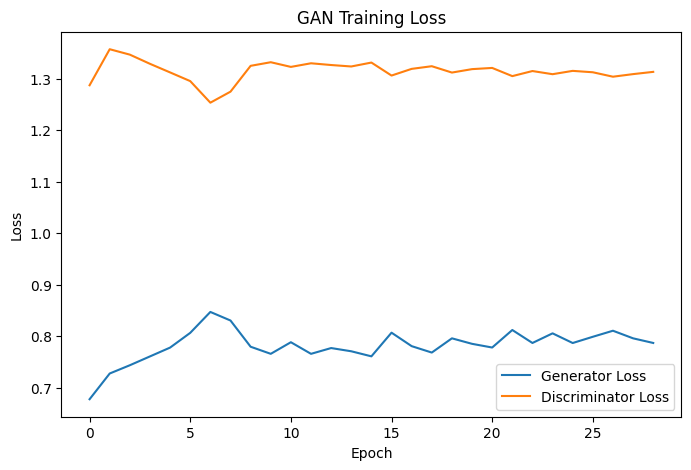

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(gen_loss_history, label="Generator Loss")
plt.plot(disc_loss_history, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()
plt.show()